In [1]:
#%pip install roboflow

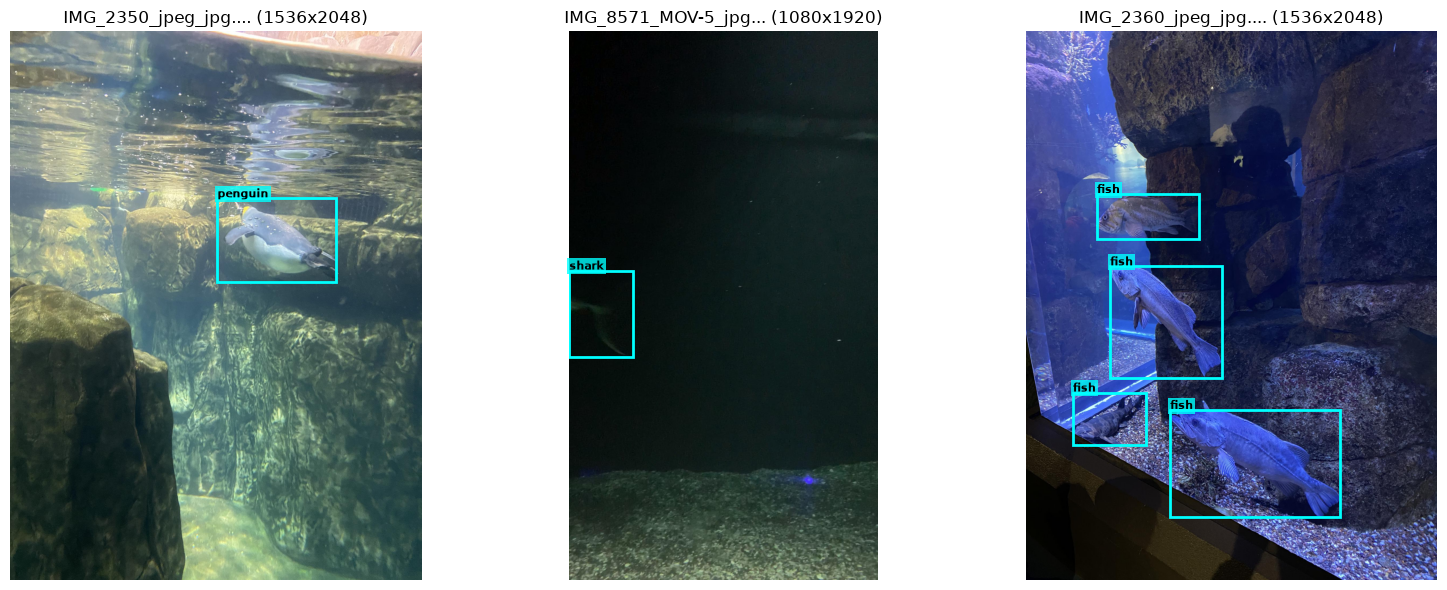

In [2]:
import json
import os
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

# Ruta al conjunto de entrenamiento
dataset_dir = "Aquarium-Combined-6/train"
ann_path = os.path.join(dataset_dir, "_annotations.coco.json")

with open(ann_path, "r") as f:
    coco_data = json.load(f)

# Diccionarios de mapeo
categories = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
img_to_anns = {}
for ann in coco_data["annotations"]:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

# Seleccionar 3 imágenes al azar con anotaciones
images_with_anns = [
    img for img in coco_data["images"] if img["id"] in img_to_anns
]
sample_images = random.sample(images_with_anns, min(3, len(images_with_anns)))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, img_info in zip(axes, sample_images):
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{img_info['file_name'][:18]}... ({img_info['width']}x{img_info['height']})"
    )

    for ann in img_to_anns.get(img_info["id"], []):
        # Formato COCO bbox: [x_min, y_min, width, height]
        x, y, w, h = ann["bbox"]
        label = categories.get(ann["category_id"], "Obj")

        rect = patches.Rectangle(
            (x, y), w, h, linewidth=2, edgecolor="cyan", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x,
            max(0, y - 4),
            label,
            color="black",
            fontsize=8,
            weight="bold",
            bbox=dict(
                boxstyle="square,pad=0.2",
                facecolor="cyan",
                edgecolor="none",
                alpha=0.8,
            ),
        )

plt.tight_layout()
plt.show()

# **Modulo 1:** Backbone que expone mapa espacial

Especificación: sea F(x) = f4(f3(f2(f1(x)))) la composición de los 4 bloques convolucionales de FundidoraPC, cada uno Conv3×3 → BatchNorm → ReLU → MaxPool2×2. 
Actualmente el forward aplica GlobalAvgPool(F(x)) y retorna un vector de dimensión 256. Para el RPN se necesitan ambas salidas; el vector pooled (compatibilidad con clasificación) y el mapa F(x) ∈ R^{256×H×W} sin poolear.
Tarea: modificar FundidoraPC.forward para que retorne una tupla (pooled: Tensor[B,256], feature_map: Tensor[B,256,H,W]). No cambiar out_features ni la firma de construcción del backbone  DualHeadDetector debe seguir funcionando llamando solo al primer elemento de la tupla.
Criterio de aceptación: con una imagen de 224×224 de entrada, feature_map.shape debe ser [B, 256, 14, 14] (4 MaxPool de stride 2 → 224/16=14). Si el H,W no da 14, revisar que no se esté agregando un pooling extra.

In [3]:
import torch
import torch.nn as nn
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


class FundidoraPC(nn.Module):
    '''
    Backbone extractor de características modificado para Taller 3.
    4 bloques conv -> BN -> ReLU -> MaxPool.
    Retorna tanto el vector global promediado como el mapa espacial sin colapsar.
    '''
    def __init__(self, in_channels=3):
        super().__init__()
        # Bloque 1: (B, 3, 224, 224) -> (B, 32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Bloque 2: (B, 32, 112, 112) -> (B, 64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Bloque 3: (B, 64, 56, 56) -> (B, 128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Bloque 4: (B, 128, 28, 28) -> (B, 256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        # Pooling global adaptativo (mantiene compatibilidad previa)
        self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.out_features = 256

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        feature_map = self.pool4(torch.relu(self.bn4(self.conv4(x)))) # [B, 256, 14, 14]

        # Vector colapsado para clasificación/compatibilidad: [B, 256]
        pooled = self.global_pool(feature_map).flatten(start_dim=1)

        return pooled, feature_map


In [4]:
# Verificación de formas y criterios de aceptación
dummy_input = torch.randn(4, 3, 224, 224)
model_backbone = FundidoraPC()
pooled_out, feat_map = model_backbone(dummy_input)

print(f"Shape pooled:      {pooled_out.shape} -> Esperado: (4, 256)")
print(f"Shape feature_map: {feat_map.shape} -> Esperado: (4, 256, 14, 14)")

# Aserciones estrictas
assert pooled_out.shape == (4, 256), f"Error en pooled: {pooled_out.shape}"
assert feat_map.shape == (4, 256, 14, 14), f"Error en feature_map: {feat_map.shape}"
assert hasattr(model_backbone, 'out_features') and model_backbone.out_features == 256, "out_features modificado"

# Verificación de compatibilidad con DualHeadDetector (tomando elemento 0)
class DualHeadDetectorTest(nn.Module):
    def __init__(self, backbone, num_classes=3):
        super().__init__()
        self.backbone = backbone
        self.cls_head = nn.Linear(backbone.out_features, num_classes)
        self.bbox_head = nn.Linear(backbone.out_features, 4)

    def forward(self, x):
        # Llama a la tupla y toma solo el primer elemento
        v = self.backbone(x)[0]
        return self.cls_head(v), torch.sigmoid(self.bbox_head(v))

test_dual = DualHeadDetectorTest(model_backbone)
logits_test, bbox_test = test_dual(dummy_input)
assert logits_test.shape == (4, 3) and bbox_test.shape == (4, 4), "DualHeadDetector falló"
print("\n✓ Criterio de aceptación del Módulo 1 superado exitosamente.")

Shape pooled:      torch.Size([4, 256]) -> Esperado: (4, 256)
Shape feature_map: torch.Size([4, 256, 14, 14]) -> Esperado: (4, 256, 14, 14)

✓ Criterio de aceptación del Módulo 1 superado exitosamente.


In [5]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class AquariumDataset(Dataset):
    """
    Dataset COCO de Roboflow adaptado al Taller 3.

    Convenciones:
    - label 0 queda reservado para background/fondo.
    - labels 1..7 corresponden a las clases reales del acuario.
    - category_id 0 ("creatures") se ignora porque no tiene cajas reales anotadas.
    - por defecto se conservan solo imágenes con al menos 2 objetos válidos.
    """
    def __init__(self, root_dir, split="train", target_size=(224, 224), min_objects=2):
        super().__init__()
        self.split_dir = os.path.join(root_dir, split)
        self.target_w, self.target_h = target_size
        self.min_objects = min_objects
        self.ann_path = os.path.join(self.split_dir, "_annotations.coco.json")

        with open(self.ann_path, "r") as f:
            self.coco_data = json.load(f)

        self.categories_raw = {cat["id"]: cat["name"] for cat in self.coco_data["categories"]}
        self.object_categories = {
            cat["id"]: cat["name"]
            for cat in self.coco_data["categories"]
            if cat["id"] != 0
        }
        self.label_to_name = {0: "background", **self.object_categories}
        self.num_object_classes = len(self.object_categories)
        self.num_classes = self.num_object_classes + 1  # C + 1, incluyendo background

        self.img_to_anns = {}
        for ann in self.coco_data["annotations"]:
            if ann["category_id"] == 0:
                continue
            if ann["bbox"][2] <= 0 or ann["bbox"][3] <= 0:
                continue
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        self.images_info = [
            img for img in self.coco_data["images"]
            if len(self.img_to_anns.get(img["id"], [])) >= self.min_objects
        ]

        self.transform = T.Compose([
            T.Resize(target_size),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.images_info)

    def __getitem__(self, idx):
        img_info = self.images_info[idx]
        img_path = os.path.join(self.split_dir, img_info["file_name"])
        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        scale_x = self.target_w / orig_w
        scale_y = self.target_h / orig_h

        boxes = []
        labels = []
        for ann in self.img_to_anns.get(img_info["id"], []):
            x, y, w, h = ann["bbox"]
            x1 = max(0.0, min(float(x * scale_x), float(self.target_w)))
            y1 = max(0.0, min(float(y * scale_y), float(self.target_h)))
            x2 = max(0.0, min(float((x + w) * scale_x), float(self.target_w)))
            y2 = max(0.0, min(float((y + h) * scale_y), float(self.target_h)))

            if (x2 - x1) >= 2.0 and (y2 - y1) >= 2.0:
                boxes.append([x1, y1, x2, y2])
                labels.append(int(ann["category_id"]))  # 1..7; 0 queda para background

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        img_tensor = self.transform(img)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(img_info["id"], dtype=torch.int64),
        }
        return img_tensor, target


def collate_fn_multiobject(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    targets = [item[1] for item in batch]
    return images, targets


In [6]:
DATASET_PATH = "Aquarium-Combined-6"

train_dataset = AquariumDataset(root_dir=DATASET_PATH, split="train", target_size=(224, 224), min_objects=2)
val_dataset = AquariumDataset(root_dir=DATASET_PATH, split="valid", target_size=(224, 224), min_objects=2)

generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    generator=generator,
    collate_fn=collate_fn_multiobject,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn_multiobject,
)

print(f"Número total de imágenes multiobjeto de train: {len(train_dataset)}")
print(f"Número total de imágenes multiobjeto de valid: {len(val_dataset)}")
print(f"Clases para la cabeza de detección ({train_dataset.num_classes}): {train_dataset.label_to_name}")

sample_images, sample_targets = next(iter(train_loader))
print(f"\nBatch imágenes shape: {sample_images.shape} -> Esperado: (4, 3, 224, 224)")

for i, target in enumerate(sample_targets):
    labels_ok = bool(((target["labels"] >= 1) & (target["labels"] <= 7)).all())
    print(f"  Img {i} -> {len(target['boxes'])} objetos | boxes {target['boxes'].shape} | labels 1..7: {labels_ok}")
    assert len(target["boxes"]) >= 2, "Cada imagen del taller debe tener al menos 2 objetos válidos"
    assert labels_ok, "Los labels de objetos deben estar entre 1 y 7; 0 se reserva para background"

with torch.no_grad():
    pooled, feat_map = model_backbone(sample_images)

assert feat_map.shape == (4, 256, 14, 14), "Error: feat_map no coincide con (4, 256, 14, 14)"
print("\n✓ Pipeline multiobjeto y enlace con FundidoraPC funcionando correctamente.")


Número total de imágenes multiobjeto de train: 352
Número total de imágenes multiobjeto de valid: 101
Clases para la cabeza de detección (8): {0: 'background', 1: 'fish', 2: 'jellyfish', 3: 'penguin', 4: 'puffin', 5: 'shark', 6: 'starfish', 7: 'stingray'}

Batch imágenes shape: torch.Size([4, 3, 224, 224]) -> Esperado: (4, 3, 224, 224)
  Img 0 -> 3 objetos | boxes torch.Size([3, 4]) | labels 1..7: True
  Img 1 -> 4 objetos | boxes torch.Size([4, 4]) | labels 1..7: True
  Img 2 -> 3 objetos | boxes torch.Size([3, 4]) | labels 1..7: True
  Img 3 -> 3 objetos | boxes torch.Size([3, 4]) | labels 1..7: True

✓ Pipeline multiobjeto y enlace con FundidoraPC funcionando correctamente.


### Checkpoint - Módulo 1 (Trazabilidad IA)

* **Qué se le pidió a la IA (Prompt tal cual):**
  "Estoy adaptando el inicio del Taller 3 al dataset Aquarium. Necesito revisar dos cosas: primero, que `FundidoraPC` conserve la salida vectorial `[B,256]` y además entregue el mapa espacial `[B,256,14,14]`; segundo, que el dataset quede en el formato correcto para detección multiobjeto, reservando la clase `0` para background y usando solo imágenes con al menos 2 objetos anotados."

* **Qué devolvió la IA (Fragmento sin editar):**
  ```python
  class FundidoraPC(nn.Module):
      def __init__(self, in_channels=3):
          super().__init__()
          self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
          self.bn1 = nn.BatchNorm2d(32)
          self.pool1 = nn.MaxPool2d(kernel_size=2)
          self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
          self.bn2 = nn.BatchNorm2d(64)
          self.pool2 = nn.MaxPool2d(kernel_size=2)
          self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
          self.bn3 = nn.BatchNorm2d(128)
          self.pool3 = nn.MaxPool2d(kernel_size=2)
          self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
          self.bn4 = nn.BatchNorm2d(256)
          self.pool4 = nn.MaxPool2d(kernel_size=2)
          self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
          self.out_features = 256

      def forward(self, x):
          x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
          x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
          x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
          feature_map = self.pool4(torch.relu(self.bn4(self.conv4(x))))
          pooled = self.global_pool(feature_map).flatten(start_dim=1)
          return pooled, feature_map
  ```

* **Qué cambiaron y por qué:**
  Se conservó la arquitectura de `FundidoraPC` vista en clase, pero el `forward` ahora retorna dos salidas: `pooled` para compatibilidad con modelos anteriores y `feature_map` para el RPN. En el dataset se ignoró la categoría general `creatures` de Roboflow y se reservó la clase `0` para `background`; las clases reales quedaron como `1..7` (`fish`, `jellyfish`, `penguin`, `puffin`, `shark`, `starfish`, `stingray`). También se filtraron las imágenes para conservar solo ejemplos con al menos 2 cajas válidas, porque el taller exige un dataset multiobjeto y no imágenes de un solo objeto.


# **Modulo 2:** Region Proposal Network, anchors y asignación por IoU

En este módulo se construye la primera etapa de Faster R-CNN reducido: el RPN. La red recibe el `feature_map` de FundidoraPC, predice objectness por ancla y deltas de caja, y luego las anclas se etiquetan comparando contra las cajas reales mediante IoU.


### Alineación con los ejemplos de clase

Este módulo sigue la notación de `Semana7_Sesion1_RCNN.ipynb`: las anclas se generan desde una celda central `(cx, cy)`, usando escalas y `aspect_ratios` interpretados como `w/h`; la asignación de etiquetas compara anclas contra cajas reales con IoU; y los offsets `(tx, ty, tw, th)` son el mismo par `calcular_offsets` / `decodificar_offsets` visto en clase, reescrito en tensores de PyTorch para poder entrenar con gradientes.


### Diagnóstico de tamaños para justificar anchors

Esta idea se rescata de la solución de referencia revisada: antes de fijar las escalas de anchors, mirar la distribución de tamaños reales de las cajas del dataset. Esto ayuda a justificar la decisión de usar escalas `16, 32, 64` en el RPN.


Resumen de tamaños reales de objetos en train, ya redimensionados a 224x224
Cantidad de cajas: 3219
Lado equivalente min: 2.1
p25: 11.9
mediana: 18.8
p75: 30.0
max: 179.0


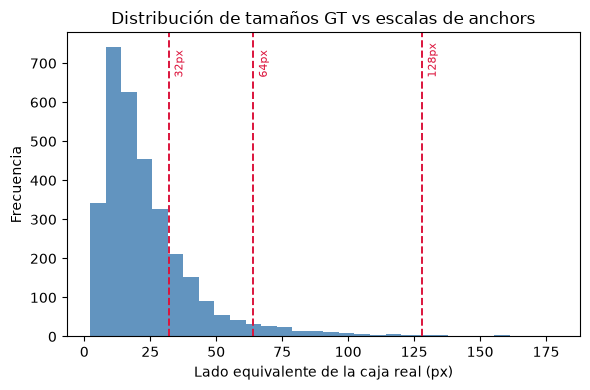

In [7]:
def analizar_tamanos_cajas_dataset(dataset):
    anchos, altos = [], []
    for idx in range(len(dataset)):
        _, target = dataset[idx]
        boxes = target["boxes"]
        wh = boxes[:, 2:] - boxes[:, :2]
        anchos.extend(wh[:, 0].tolist())
        altos.extend(wh[:, 1].tolist())

    anchos = np.array(anchos)
    altos = np.array(altos)
    lados_equivalentes = np.sqrt(anchos * altos)

    print("Resumen de tamaños reales de objetos en train, ya redimensionados a 224x224")
    print(f"Cantidad de cajas: {len(lados_equivalentes)}")
    print(f"Lado equivalente min: {lados_equivalentes.min():.1f}")
    print(f"p25: {np.percentile(lados_equivalentes, 25):.1f}")
    print(f"mediana: {np.median(lados_equivalentes):.1f}")
    print(f"p75: {np.percentile(lados_equivalentes, 75):.1f}")
    print(f"max: {lados_equivalentes.max():.1f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(lados_equivalentes, bins=30, color="steelblue", alpha=0.85)
    for escala in [32, 64, 128]:
        ax.axvline(escala, color="crimson", linestyle="--", linewidth=1.4)
        ax.text(escala + 2, ax.get_ylim()[1] * 0.86, f"{escala}px", rotation=90, color="crimson", fontsize=8)
    ax.set_xlabel("Lado equivalente de la caja real (px)")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribución de tamaños GT vs escalas de anchors")
    plt.tight_layout()
    plt.show()

    return lados_equivalentes

lados_equivalentes_train = analizar_tamanos_cajas_dataset(train_dataset)


In [8]:
import math
import torch.nn.functional as F

class RPNHead(nn.Module):
    """
    Cabeza RPN liviana: conv 3x3 compartida + objectness + regresión de caja.
    Entrada:  [B, 256, H, W]
    Salidas:  objectness [B, k, H, W], bbox_deltas [B, 4k, H, W]
    """
    def __init__(self, in_channels=256, num_anchors=9):
        super().__init__()
        self.num_anchors = num_anchors
        self.shared = nn.Conv2d(in_channels, 256, kernel_size=3, padding=1)
        self.objectness = nn.Conv2d(256, num_anchors, kernel_size=1)
        self.bbox_deltas = nn.Conv2d(256, 4 * num_anchors, kernel_size=1)

    def forward(self, feature_map):
        t = F.relu(self.shared(feature_map))
        return self.objectness(t), self.bbox_deltas(t)


def generar_anclas_celda(cx, cy, escalas, aspect_ratios):
    """
    Versión PyTorch del ejemplo de Semana 7.
    aspect_ratio se interpreta como w/h, igual que en clase:
    w = escala * sqrt(ar), h = escala / sqrt(ar).
    """
    anclas = []
    for escala in escalas:
        for ar in aspect_ratios:
            w = escala * math.sqrt(ar)
            h = escala / math.sqrt(ar)
            anclas.append([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])
    return anclas


def generate_anchors(feature_size=(14, 14), image_size=(224, 224), scales=(16, 32, 64), ratios=(0.5, 1.0, 2.0)):
    """
    Genera k=len(scales)*len(ratios) anclas por celda del mapa HxW.
    Mantiene la lógica de generar_anclas_grilla vista en clase, adaptada a mapas no necesariamente cuadrados.
    Retorna cajas [N, 4] en formato x1, y1, x2, y2 en coordenadas de imagen.
    """
    feat_h, feat_w = feature_size
    img_h, img_w = image_size
    stride_y = img_h / feat_h
    stride_x = img_w / feat_w

    anchors = []
    for fila in range(feat_h):
        for col in range(feat_w):
            cx = (col + 0.5) * stride_x
            cy = (fila + 0.5) * stride_y
            anchors.extend(generar_anclas_celda(cx, cy, scales, ratios))

    anchors = torch.tensor(anchors, dtype=torch.float32)
    anchors[:, 0::2] = anchors[:, 0::2].clamp(min=0, max=img_w)
    anchors[:, 1::2] = anchors[:, 1::2].clamp(min=0, max=img_h)
    return anchors


def box_area(boxes):
    return (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (boxes[:, 3] - boxes[:, 1]).clamp(min=0)


def box_iou(boxes1, boxes2):
    """Equivalente vectorizado en PyTorch de iou_matriz(cajas_a, cajas_b) de Semana 7."""
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=boxes1.dtype, device=boxes1.device)

    lt = torch.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = box_area(boxes1)[:, None] + box_area(boxes2)[None, :] - inter
    return inter / union.clamp(min=1e-6)


def calcular_offsets(anclas, cajas_reales):
    """Versión por lotes de calcular_offsets(ancla, caja_real) visto en clase."""
    anchor_w = (anclas[:, 2] - anclas[:, 0]).clamp(min=1e-6)
    anchor_h = (anclas[:, 3] - anclas[:, 1]).clamp(min=1e-6)
    anchor_cx = anclas[:, 0] + 0.5 * anchor_w
    anchor_cy = anclas[:, 1] + 0.5 * anchor_h

    gt_w = (cajas_reales[:, 2] - cajas_reales[:, 0]).clamp(min=1e-6)
    gt_h = (cajas_reales[:, 3] - cajas_reales[:, 1]).clamp(min=1e-6)
    gt_cx = cajas_reales[:, 0] + 0.5 * gt_w
    gt_cy = cajas_reales[:, 1] + 0.5 * gt_h

    tx = (gt_cx - anchor_cx) / anchor_w
    ty = (gt_cy - anchor_cy) / anchor_h
    tw = torch.log(gt_w / anchor_w)
    th = torch.log(gt_h / anchor_h)
    return torch.stack([tx, ty, tw, th], dim=1)


def encode_boxes(anchors, gt_boxes):
    return calcular_offsets(anchors, gt_boxes)


def assign_targets(anchors, gt_boxes, pos_iou=0.7, neg_iou=0.3):
    """
    Etiqueta anclas como positiva=1, negativa=0 o ignorada=-1.
    Además calcula deltas objetivo para las anclas positivas.
    """
    device = anchors.device
    gt_boxes = gt_boxes.to(device)
    labels = torch.full((anchors.shape[0],), -1, dtype=torch.int64, device=device)
    target_deltas = torch.zeros((anchors.shape[0], 4), dtype=torch.float32, device=device)

    if gt_boxes.numel() == 0:
        labels[:] = 0
        return labels, target_deltas

    ious = box_iou(anchors, gt_boxes)
    max_iou, matched_gt_idx = ious.max(dim=1)

    labels[max_iou <= neg_iou] = 0
    labels[max_iou >= pos_iou] = 1

    # Igual que en clase: la mejor ancla de cada ground truth siempre es positiva.
    best_anchor_per_gt = ious.argmax(dim=0)
    labels[best_anchor_per_gt] = 1
    matched_gt_idx[best_anchor_per_gt] = torch.arange(gt_boxes.shape[0], device=device)

    positive_idx = labels == 1
    if positive_idx.any():
        target_deltas[positive_idx] = encode_boxes(anchors[positive_idx], gt_boxes[matched_gt_idx[positive_idx]])

    return labels, target_deltas


def sample_rpn_targets(labels, batch_size=256, positive_fraction=0.5):
    """Muestreo balanceado de anclas positivas y negativas para la loss del RPN."""
    positive_idx = torch.where(labels == 1)[0]
    negative_idx = torch.where(labels == 0)[0]

    max_pos = int(batch_size * positive_fraction)
    num_pos = min(len(positive_idx), max_pos)
    num_neg = min(len(negative_idx), batch_size - num_pos)

    if len(positive_idx) > 0:
        positive_idx = positive_idx[torch.randperm(len(positive_idx), device=labels.device)[:num_pos]]
    if len(negative_idx) > 0:
        negative_idx = negative_idx[torch.randperm(len(negative_idx), device=labels.device)[:num_neg]]

    return torch.cat([positive_idx, negative_idx], dim=0)


In [9]:
# Verificación del Módulo 2 con un batch real del acuario
rpn_head = RPNHead(in_channels=256, num_anchors=9)

with torch.no_grad():
    _, feature_map = model_backbone(sample_images)
    objectness_logits, rpn_bbox_deltas = rpn_head(feature_map)

print(f"Feature map:       {feature_map.shape} -> Esperado: (4, 256, 14, 14)")
print(f"Objectness logits: {objectness_logits.shape} -> Esperado: (4, 9, 14, 14)")
print(f"RPN bbox deltas:   {rpn_bbox_deltas.shape} -> Esperado: (4, 36, 14, 14)")

anchors = generate_anchors(feature_size=(14, 14), image_size=(224, 224))
print(f"Anchors: {anchors.shape} -> Esperado: (14*14*9=1764, 4)")

labels, target_deltas = assign_targets(anchors, sample_targets[0]["boxes"])
sampled_idx = sample_rpn_targets(labels)

num_pos = int((labels == 1).sum())
num_neg = int((labels == 0).sum())
num_ign = int((labels == -1).sum())
print(f"Etiquetas RPN imagen 0 -> positivas: {num_pos}, negativas: {num_neg}, ignoradas: {num_ign}")
print(f"Muestra balanceada: {sampled_idx.numel()} anclas")
print(f"Deltas objetivo: {target_deltas.shape}")

assert objectness_logits.shape == (4, 9, 14, 14)
assert rpn_bbox_deltas.shape == (4, 36, 14, 14)
assert anchors.shape == (1764, 4)
assert target_deltas.shape == anchors.shape
assert num_pos >= len(sample_targets[0]["boxes"]), "Debe haber al menos una ancla positiva por GT box"
assert sampled_idx.numel() <= 256
print("\n✓ RPNHead, anchors y assign_targets pasan la verificación básica del Módulo 2.")


Feature map:       torch.Size([4, 256, 14, 14]) -> Esperado: (4, 256, 14, 14)
Objectness logits: torch.Size([4, 9, 14, 14]) -> Esperado: (4, 9, 14, 14)
RPN bbox deltas:   torch.Size([4, 36, 14, 14]) -> Esperado: (4, 36, 14, 14)
Anchors: torch.Size([1764, 4]) -> Esperado: (14*14*9=1764, 4)
Etiquetas RPN imagen 0 -> positivas: 3, negativas: 1732, ignoradas: 29
Muestra balanceada: 256 anclas
Deltas objetivo: torch.Size([1764, 4])

✓ RPNHead, anchors y assign_targets pasan la verificación básica del Módulo 2.


In [10]:
from torchvision.ops import nms


def nms_manual_torch(cajas, puntajes, iou_umbral=0.5):
    """Versión PyTorch del nms_manual visto en Semana 7; útil para explicar el mecanismo."""
    orden = torch.argsort(puntajes, descending=True)
    mantener = []
    while orden.numel() > 0:
        i = orden[0]
        mantener.append(i)
        if orden.numel() == 1:
            break
        resto = orden[1:]
        ious_con_i = box_iou(cajas[i:i + 1], cajas[resto])[0]
        orden = resto[ious_con_i <= iou_umbral]
    if len(mantener) == 0:
        return torch.empty((0,), dtype=torch.long, device=cajas.device)
    return torch.stack(mantener)



def flatten_rpn_outputs(objectness_logits, bbox_deltas):
    """
    Convierte salidas del RPN a formato alineado con generate_anchors:
    objectness [B,k,H,W] -> [B,H*W*k]
    deltas     [B,4k,H,W] -> [B,H*W*k,4]
    """
    B, k, H, W = objectness_logits.shape
    objectness_flat = objectness_logits.permute(0, 2, 3, 1).reshape(B, -1)
    deltas_flat = bbox_deltas.reshape(B, k, 4, H, W).permute(0, 3, 4, 1, 2).reshape(B, -1, 4)
    return objectness_flat, deltas_flat


def rpn_loss_single_image(objectness_logits_flat, bbox_deltas_flat, labels, target_deltas, sampled_idx):
    """Loss RPN para una imagen: BCE objectness + SmoothL1 solo en positivas."""
    sampled_labels = labels[sampled_idx].float()
    sampled_objectness = objectness_logits_flat[sampled_idx]
    objectness_loss = F.binary_cross_entropy_with_logits(sampled_objectness, sampled_labels)

    positive_sampled = sampled_idx[labels[sampled_idx] == 1]
    if positive_sampled.numel() == 0:
        regression_loss = bbox_deltas_flat.sum() * 0.0
    else:
        regression_loss = F.smooth_l1_loss(
            bbox_deltas_flat[positive_sampled],
            target_deltas[positive_sampled],
            beta=1.0 / 9.0,
            reduction="mean",
        )
    return objectness_loss + regression_loss, objectness_loss.detach(), regression_loss.detach()


def rpn_loss_batch(objectness_logits, bbox_deltas, anchors, targets, batch_size_per_image=256):
    objectness_flat, bbox_deltas_flat = flatten_rpn_outputs(objectness_logits, bbox_deltas)
    total_loss = 0.0
    cls_losses = []
    reg_losses = []

    for b, target in enumerate(targets):
        labels, target_deltas = assign_targets(anchors.to(bbox_deltas.device), target["boxes"].to(bbox_deltas.device))
        sampled_idx = sample_rpn_targets(labels, batch_size=batch_size_per_image)
        loss, cls_loss, reg_loss = rpn_loss_single_image(
            objectness_flat[b], bbox_deltas_flat[b], labels, target_deltas, sampled_idx
        )
        total_loss = total_loss + loss
        cls_losses.append(cls_loss)
        reg_losses.append(reg_loss)

    total_loss = total_loss / len(targets)
    return total_loss, torch.stack(cls_losses).mean(), torch.stack(reg_losses).mean()


def decode_boxes(anchors, deltas):
    """Aplica deltas predichos sobre anchors y devuelve propuestas x1,y1,x2,y2."""
    widths = (anchors[:, 2] - anchors[:, 0]).clamp(min=1e-6)
    heights = (anchors[:, 3] - anchors[:, 1]).clamp(min=1e-6)
    ctr_x = anchors[:, 0] + 0.5 * widths
    ctr_y = anchors[:, 1] + 0.5 * heights

    dx, dy, dw, dh = deltas.unbind(dim=1)
    dw = dw.clamp(max=math.log(224.0 / 2.0))
    dh = dh.clamp(max=math.log(224.0 / 2.0))

    pred_ctr_x = dx * widths + ctr_x
    pred_ctr_y = dy * heights + ctr_y
    pred_w = torch.exp(dw) * widths
    pred_h = torch.exp(dh) * heights

    x1 = pred_ctr_x - 0.5 * pred_w
    y1 = pred_ctr_y - 0.5 * pred_h
    x2 = pred_ctr_x + 0.5 * pred_w
    y2 = pred_ctr_y + 0.5 * pred_h
    return torch.stack([x1, y1, x2, y2], dim=1)


def clip_boxes_to_image(boxes, image_size=(224, 224)):
    h, w = image_size
    boxes = boxes.clone()
    boxes[:, 0::2] = boxes[:, 0::2].clamp(min=0, max=w)
    boxes[:, 1::2] = boxes[:, 1::2].clamp(min=0, max=h)
    return boxes


def remove_small_boxes(boxes, min_size=2.0):
    ws = boxes[:, 2] - boxes[:, 0]
    hs = boxes[:, 3] - boxes[:, 1]
    return torch.where((ws >= min_size) & (hs >= min_size))[0]


def filter_proposals(objectness_logits_flat, bbox_deltas_flat, anchors, image_size=(224, 224), pre_nms_top_n=600, post_nms_top_n=100, nms_thresh=0.7):
    """Decodifica propuestas del RPN, filtra cajas pequeñas y aplica NMS."""
    scores = torch.sigmoid(objectness_logits_flat)
    anchors = anchors.to(bbox_deltas_flat.device)
    proposals = decode_boxes(anchors, bbox_deltas_flat)
    proposals = clip_boxes_to_image(proposals, image_size=image_size)

    keep = remove_small_boxes(proposals)
    proposals = proposals[keep]
    scores = scores[keep]

    num_top = min(pre_nms_top_n, scores.numel())
    top_scores, top_idx = scores.topk(num_top)
    proposals = proposals[top_idx]

    keep_nms = nms(proposals, top_scores, nms_thresh)
    keep_nms = keep_nms[:post_nms_top_n]
    return proposals[keep_nms], top_scores[keep_nms]


In [11]:
# Verificación de loss del RPN y generación de propuestas
objectness_logits, rpn_bbox_deltas = rpn_head(feature_map)
rpn_total_loss, rpn_cls_loss, rpn_reg_loss = rpn_loss_batch(
    objectness_logits, rpn_bbox_deltas, anchors, sample_targets
)
print(f"RPN loss total: {float(rpn_total_loss.detach()):.4f}")
print(f"  objectness BCE: {float(rpn_cls_loss):.4f}")
print(f"  bbox SmoothL1:  {float(rpn_reg_loss):.4f}")

objectness_flat, bbox_deltas_flat = flatten_rpn_outputs(objectness_logits, rpn_bbox_deltas)
proposals_img0, proposal_scores_img0 = filter_proposals(
    objectness_flat[0], bbox_deltas_flat[0], anchors, post_nms_top_n=50
)

print(f"Propuestas imagen 0 tras NMS: {proposals_img0.shape}")
print(f"Scores propuestas: {proposal_scores_img0.shape}")

assert rpn_total_loss.ndim == 0
assert proposals_img0.shape[1] == 4
assert proposals_img0.shape[0] <= 50
assert torch.isfinite(rpn_total_loss), "La loss del RPN debe ser finita"
print("\n✓ Loss RPN y propuestas con NMS funcionando.")


RPN loss total: 0.8783
  objectness BCE: 0.7010
  bbox SmoothL1:  0.1773
Propuestas imagen 0 tras NMS: torch.Size([50, 4])
Scores propuestas: torch.Size([50])

✓ Loss RPN y propuestas con NMS funcionando.


### Métrica obligatoria del RPN: recall de propuestas

El criterio de aceptación del Módulo 2 pide revisar si las propuestas del RPN cubren las cajas reales. Para eso medimos recall@IoU=0.5: una caja real cuenta como recuperada si al menos una propuesta tiene IoU mayor o igual a `0.5` con ella.


In [12]:
def proposal_recall(proposals, gt_boxes, iou_thresh=0.5):
    """
    Fracción de cajas ground-truth cubiertas por al menos una propuesta.
    Esta es la métrica pedida para validar si el RPN está proponiendo regiones útiles.
    """
    if gt_boxes.numel() == 0:
        return 0.0
    if proposals.numel() == 0:
        return 0.0
    ious = box_iou(gt_boxes.to(proposals.device), proposals.to(proposals.device))
    best_iou_per_gt = ious.max(dim=1).values
    return float((best_iou_per_gt >= iou_thresh).float().mean().item())


def proposal_recall_batch(objectness_logits, bbox_deltas, anchors, targets, iou_thresh=0.5, post_nms_top_n=100):
    objectness_flat, bbox_deltas_flat = flatten_rpn_outputs(objectness_logits, bbox_deltas)
    recalls = []
    for b, target in enumerate(targets):
        proposals, _ = filter_proposals(
            objectness_flat[b],
            bbox_deltas_flat[b],
            anchors,
            post_nms_top_n=post_nms_top_n,
        )
        recalls.append(proposal_recall(proposals, target["boxes"], iou_thresh=iou_thresh))
    return float(np.mean(recalls)), recalls

recall_promedio, recalls_por_imagen = proposal_recall_batch(
    objectness_logits,
    rpn_bbox_deltas,
    anchors,
    sample_targets,
    iou_thresh=0.5,
    post_nms_top_n=100,
)

print(f"Recall de propuestas RPN@0.5 en batch de prueba: {recall_promedio:.3f}")
print("Recall por imagen:", [round(r, 3) for r in recalls_por_imagen])
print("Nota: antes de entrenar el RPN, este valor puede ser bajo; lo importante es reportarlo por época en el Módulo 5.")


Recall de propuestas RPN@0.5 en batch de prueba: 0.146
Recall por imagen: [0.0, 0.25, 0.333, 0.0]
Nota: antes de entrenar el RPN, este valor puede ser bajo; lo importante es reportarlo por época en el Módulo 5.


### Comparación de escalas de anchors

Como el dataset Aquarium tiene muchos objetos pequeños, comparamos configuraciones de escalas usando la misma asignación por IoU. Esto no reemplaza el entrenamiento, pero ayuda a justificar la decisión de diseño sobre `scales` en el `MANIFEST_IA.md`.


In [13]:
def evaluar_config_anchors(dataset, scale_configs, ratios=(0.5, 1.0, 2.0), max_images=40):
    filas = []
    n = min(len(dataset), max_images)
    for scales in scale_configs:
        anchors_cfg = generate_anchors(
            feature_size=(14, 14),
            image_size=(224, 224),
            scales=scales,
            ratios=ratios,
        )
        pos_counts, ign_counts, neg_counts, best_ious = [], [], [], []
        for idx in range(n):
            _, target = dataset[idx]
            labels_cfg, _ = assign_targets(anchors_cfg, target["boxes"])
            pos_counts.append(int((labels_cfg == 1).sum()))
            neg_counts.append(int((labels_cfg == 0).sum()))
            ign_counts.append(int((labels_cfg == -1).sum()))
            ious = box_iou(anchors_cfg, target["boxes"])
            best_ious.extend(ious.max(dim=0).values.tolist())
        filas.append({
            "scales": scales,
            "pos_prom": float(np.mean(pos_counts)),
            "ign_prom": float(np.mean(ign_counts)),
            "neg_prom": float(np.mean(neg_counts)),
            "best_iou_gt_prom": float(np.mean(best_ious)),
            "best_iou_gt_p50": float(np.percentile(best_ious, 50)),
        })
    return filas

scale_configs = [
    (16, 32, 64),
    (24, 48, 96),
    (32, 64, 128),
]

resumen_anchors = evaluar_config_anchors(train_dataset, scale_configs, max_images=40)
print("Comparación sobre 40 imágenes multiobjeto de train")
print("scales          pos_prom  ign_prom  neg_prom  best_iou_prom  best_iou_p50")
for fila in resumen_anchors:
    print(
        f"{str(fila['scales']):15s} "
        f"{fila['pos_prom']:8.2f} "
        f"{fila['ign_prom']:8.2f} "
        f"{fila['neg_prom']:8.2f} "
        f"{fila['best_iou_gt_prom']:14.3f} "
        f"{fila['best_iou_gt_p50']:12.3f}"
    )

mejor = max(resumen_anchors, key=lambda x: x["best_iou_gt_prom"])
print(f"\nConfiguración con mejor cobertura promedio inicial: {mejor['scales']}")
print("Si el recall del RPN entrenado queda bajo, esta comparación justifica probar escalas más pequeñas.")


Comparación sobre 40 imágenes multiobjeto de train
scales          pos_prom  ign_prom  neg_prom  best_iou_prom  best_iou_p50
(16, 32, 64)       10.03    77.90  1676.08          0.485        0.491
(24, 48, 96)        9.93    99.55  1654.53          0.454        0.467
(32, 64, 128)      10.10   104.80  1649.10          0.408        0.417

Configuración con mejor cobertura promedio inicial: (16, 32, 64)
Si el recall del RPN entrenado queda bajo, esta comparación justifica probar escalas más pequeñas.


### Visualización del Módulo 2 sobre una imagen real

Esta celda traduce el flujo del RPN a una figura: primero se ven las cajas reales, luego una muestra de anchors, después la asignación positiva/fondo/ignorada por IoU y finalmente las propuestas que sobreviven a NMS.


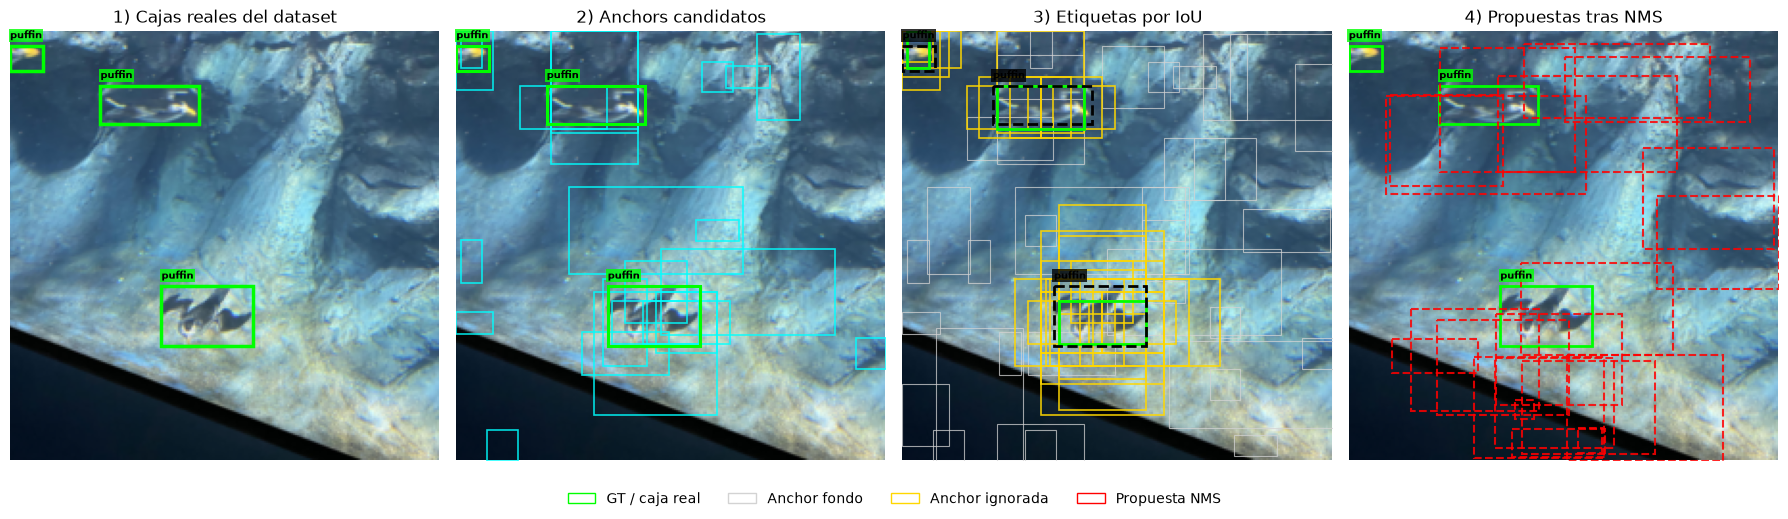

In [14]:
def denormalize_image(img_tensor):
    """Invierte la normalización ImageNet para poder visualizar la imagen del DataLoader."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).cpu().numpy()


def draw_boxes(ax, boxes, color, labels=None, linewidth=1.5, linestyle="-", alpha=1.0):
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in box]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=linewidth,
            linestyle=linestyle, alpha=alpha,
        )
        ax.add_patch(rect)
        if labels is not None:
            ax.text(
                x1, max(0, y1 - 4), str(labels[i]),
                color="black", fontsize=7, weight="bold",
                bbox=dict(boxstyle="square,pad=0.15", facecolor=color, edgecolor="none", alpha=0.8),
            )


def visualizar_modulo2_rpn(image_tensor, target, anchors, labels_rpn, proposals, label_to_name, max_neg=35, max_ign=25, max_pos=25):
    img_np = denormalize_image(image_tensor)
    gt_boxes = target["boxes"].cpu()
    gt_names = [label_to_name[int(label)] for label in target["labels"].cpu()]

    pos_idx = torch.where(labels_rpn == 1)[0].cpu()
    neg_idx = torch.where(labels_rpn == 0)[0].cpu()
    ign_idx = torch.where(labels_rpn == -1)[0].cpu()

    # Muestreo fijo para que la figura sea legible y reproducible.
    g = torch.Generator().manual_seed(SEED)
    pos_show = pos_idx[torch.randperm(len(pos_idx), generator=g)[:min(max_pos, len(pos_idx))]] if len(pos_idx) else pos_idx
    neg_show = neg_idx[torch.randperm(len(neg_idx), generator=g)[:min(max_neg, len(neg_idx))]] if len(neg_idx) else neg_idx
    ign_show = ign_idx[torch.randperm(len(ign_idx), generator=g)[:min(max_ign, len(ign_idx))]] if len(ign_idx) else ign_idx

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    titles = [
        "1) Cajas reales del dataset",
        "2) Anchors candidatos",
        "3) Etiquetas por IoU",
        "4) Propuestas tras NMS",
    ]

    for ax, title in zip(axes, titles):
        ax.imshow(img_np)
        ax.set_title(title)
        ax.set_xlim(0, 224)
        ax.set_ylim(224, 0)
        ax.axis("off")

    draw_boxes(axes[0], gt_boxes, color="lime", labels=gt_names, linewidth=2.5)

    # En el panel 2 solo mostramos algunas anchors para no saturar la imagen.
    anchor_sample = torch.cat([pos_show, ign_show[:8], neg_show[:12]])
    draw_boxes(axes[1], anchors[anchor_sample], color="cyan", linewidth=1.2, alpha=0.85)
    draw_boxes(axes[1], gt_boxes, color="lime", labels=gt_names, linewidth=2.2)

    draw_boxes(axes[2], anchors[neg_show], color="lightgray", linewidth=0.8, alpha=0.75)
    draw_boxes(axes[2], anchors[ign_show], color="gold", linewidth=1.2, alpha=0.9)
    draw_boxes(axes[2], anchors[pos_show], color="lime", linewidth=2.0)
    draw_boxes(axes[2], gt_boxes, color="black", labels=gt_names, linewidth=2.0, linestyle="--")

    draw_boxes(axes[3], gt_boxes, color="lime", labels=gt_names, linewidth=2.0)
    draw_boxes(axes[3], proposals[:20].detach().cpu(), color="red", linewidth=1.5, linestyle="--", alpha=0.85)

    legend_handles = [
        patches.Patch(edgecolor="lime", facecolor="none", label="GT / caja real"),
        patches.Patch(edgecolor="lightgray", facecolor="none", label="Anchor fondo"),
        patches.Patch(edgecolor="gold", facecolor="none", label="Anchor ignorada"),
        patches.Patch(edgecolor="red", facecolor="none", label="Propuesta NMS"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    plt.show()


visualizar_modulo2_rpn(
    image_tensor=sample_images[0],
    target=sample_targets[0],
    anchors=anchors.cpu(),
    labels_rpn=labels.cpu(),
    proposals=proposals_img0,
    label_to_name=train_dataset.label_to_name,
)


### Checkpoint - Módulo 2 (Trazabilidad IA)

* **Qué se le pidió a la IA (Prompt tal cual):**
  ""

* **Qué devolvió la IA (Fragmento sin editar):**


* **Qué cambiaron y por qué:**


# **Modulo 3:** Propuestas, detach y ROI Align

Las propuestas generadas por el RPN se usan como regiones de interés para extraer tensores fijos de tamaño `7x7`. Antes de `roi_align`, se aplica `.detach()` sobre las propuestas para separar el aprendizaje de localización del RPN del aprendizaje de clasificación/refinamiento de la segunda etapa.


In [15]:
from torchvision.ops import roi_align

# ROI Align para la primera imagen del batch.
# spatial_scale = feature_map_size / image_size = 14 / 224 = 1/16

objectness_flat, bbox_deltas_flat = flatten_rpn_outputs(
    objectness_logits,
    rpn_bbox_deltas
)

proposals = []

for b in range(feature_map.shape[0]):
    proposals_b, _ = filter_proposals(
        objectness_flat[b],
        bbox_deltas_flat[b],
        anchors,
        post_nms_top_n=50
    )
    proposals.append(proposals_b.detach())

for i, p in enumerate(proposals):
    assert not p.requires_grad, (
        f"Las propuestas de la imagen {i} deben desconectarse con detach() antes de ROI Align"
    )

roi_features = roi_align(
    input=feature_map,
    boxes=proposals,
    output_size=(7, 7),
    spatial_scale=1.0 / 16.0,
    sampling_ratio=2,
    aligned=True,
)

num_proposals = sum(p.shape[0] for p in proposals)

print(f"ROI features: {roi_features.shape} -> Esperado: [N_propuestas, 256, 7, 7]")
assert roi_features.ndim == 4
assert roi_features.shape[1:] == (256, 7, 7)
assert roi_features.shape[0] == num_proposals
print("\n✓ ROI Align recibe propuestas desconectadas y produce regiones fijas 7x7.")


ROI features: torch.Size([200, 256, 7, 7]) -> Esperado: [N_propuestas, 256, 7, 7]

✓ ROI Align recibe propuestas desconectadas y produce regiones fijas 7x7.


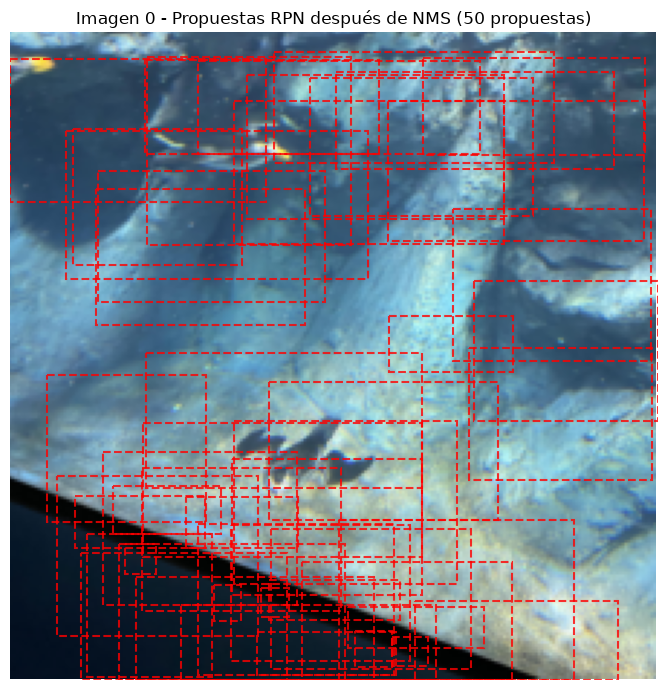

ROI features de la imagen 0: torch.Size([50, 256, 7, 7])


In [16]:
# Visualización de propuestas del Módulo 3 para una imagen

img_np = denormalize_image(sample_images[0])

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(img_np)

draw_boxes(
    ax,
    proposals[0].cpu(),
    color="red",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8
)

ax.set_title(
    f"Imagen 0 - Propuestas RPN después de NMS ({len(proposals[0])} propuestas)"
)

ax.set_xlim(0, 224)
ax.set_ylim(224, 0)
ax.axis("off")

plt.tight_layout()
plt.show()

print(f"ROI features de la imagen 0: {roi_features[:len(proposals[0])].shape}")

### Checkpoint - Módulo 3 (Trazabilidad IA)

* **Qué se le pidió a la IA (Prompt tal cual):**
  "Estoy trabajando en el Taller 3 y quiero que me ayudes únicamente con el Módulo 3: ROI Align y propuestas
   Usa mi PDF y mi notebook como base. Revisa el código que ya tengo y no asumas que existen variables que todavía no he creado

   Necesito:

  - Aplicar detach() a las propuestas después del NMS
  - Hacer el ROI Align con un tamaño 7x7
  - Comprobar que la salida tenga la forma correcta [N, 256, 7, 7]
  - Añadir una ayuda visual para comprabar que lo que hicimos es correcto o acorde a lo que estamos haciendo

  No avances al Módulo 4 ni a los siguientes. Dame solo el código necesario y después explícame brevemente qué cambios hiciste. "

* **Qué devolvió la IA (Fragmento sin editar):**
"from torchvision.ops import roi_align

# ROI Align para la primera imagen del batch.
# spatial_scale = feature_map_size / image_size = 14 / 224 = 1/16
proposals_for_roi = proposals_img0.detach()
assert not proposals_for_roi.requires_grad, "Las propuestas deben desconectarse con detach() antes de ROI Align"

roi_features = roi_align(
    input=feature_map[0:1],
    boxes=[proposals_for_roi],
    output_size=(7, 7),
    spatial_scale=1.0 / 16.0,
    sampling_ratio=2,
    aligned=True,
)

print(f"ROI features: {roi_features.shape} -> Esperado: [N_propuestas, 256, 7, 7]")
assert roi_features.ndim == 4
assert roi_features.shape[1:] == (256, 7, 7)
assert roi_features.shape[0] == proposals_for_roi.shape[0]
print("\n✓ ROI Align recibe propuestas desconectadas y produce regiones fijas 7x7.")
"

* **Qué cambiaron y por qué:**
"Se cambio para que hiciera el proceso fuera con todas las imagenes y no con solo una en especifica, todo lo dejamas se dejo igual"


# **Modulo 4:** Cabeza de detección por propuesta

La segunda etapa recibe regiones `7x7x256` producidas por ROI Align. Para cada propuesta decide una clase entre `C+1` opciones (`background` + 7 animales) y predice un refinamiento de caja clase-agnóstico.


### 1. Arquitectura: Cabeza de Detección (Fast R-CNN Head)
Define la red densa encargada de procesar las regiones de interés extraídas por `RoIAlign`[cite: 1, 3]. 
- **Entrada:** Tensores de características alineadas con dimensión `[N, in_channels, 7, 7]`[cite: 1, 3].
- **Procesamiento:** Aplana la cuadrícula espacial (`256 × 7 × 7 = 12,544`) y la proyecta mediante capas densas con activación ReLU y Dropout[cite: 1, 3].
- **Salidas paralelas:**
  1. `class_logits` con tamaño `[N, num_classes]`: puntajes para las $C$ categorías más la clase fondo ($0$)[cite: 1, 3].
  2. `bbox_refine` con tamaño `[N, 4]`: factores de ajuste agnósticos a la clase ($t_x, t_y, t_w, t_h$) para refinar la geometría de cada propuesta[cite: 1, 3].

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.ops import box_iou, roi_align

class DetectionHead(nn.Module):
    """
    Cabeza de detección por propuesta (Fast R-CNN Head).
    Entrada:  roi_features [N, 256, 7, 7]
    Salidas:  class_logits [N, num_classes], bbox_refine [N, 4]
    """
    def __init__(self, in_channels=256, roi_size=7, hidden_dim=256, num_classes=8, dropout=0.1):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_channels * roi_size * roi_size, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.bbox_refine = nn.Linear(hidden_dim, 4)

    def forward(self, roi_features):
        x = self.flatten(roi_features)
        x = F.relu(self.fc(x))
        x = self.dropout(x)
        class_logits = self.classifier(x)
        bbox_refine = self.bbox_refine(x)
        return class_logits, bbox_refine

### 2. Asignación y Muestreo de Objetivos (Target Assignment)
Etiqueta las propuestas candidatas del RPN contra las anotaciones reales (Ground Truth) y extrae un subconjunto balanceado para el entrenamiento[cite: 1, 3]:
- **Inyección de GT:** Concatena las cajas reales al conjunto de propuestas para asegurar la existencia de muestras positivas desde las primeras épocas[cite: 1, 3].
- **Criterio de solapamiento:** Las propuestas con $\text{IoU} \ge 0.5$ se consideran objetos positivos y calculan sus desplazamientos objetivo (`encode_boxes`); las propuestas con $\text{IoU} < 0.5$ se clasifican como fondo (`clase 0`)[cite: 1, 3].
- **Balanceo:** Selecciona un subconjunto de tamaño fijo (ej. 64 propuestas) manteniendo una proporción de 25% de objetos y 75% de fondo para evitar el sesgo hacia la clase mayoritaria[cite: 1, 3].

In [18]:
def assign_proposal_targets(proposals, gt_boxes, gt_labels, pos_iou=0.5, batch_size=64, positive_fraction=0.25):
    """
    Etiqueta y balancea propuestas para la segunda etapa.
    - IoU >= 0.5: positivo (hereda la clase de la GT más cercana).
    - IoU < 0.5: fondo (clase 0).
    Retorna: propuestas muestreadas [M, 4], etiquetas [M], deltas objetivo [M, 4].
    """
    device = proposals.device
    gt_boxes = gt_boxes.to(device)
    gt_labels = gt_labels.to(device)

    # Inyección de GT boxes para garantizar positivos aun con RPN sin entrenar
    if gt_boxes.numel() > 0:
        proposals = torch.cat([proposals, gt_boxes], dim=0)

    if proposals.numel() == 0:
        empty_boxes = torch.zeros((0, 4), dtype=torch.float32, device=device)
        empty_labels = torch.zeros((0,), dtype=torch.int64, device=device)
        empty_deltas = torch.zeros((0, 4), dtype=torch.float32, device=device)
        return empty_boxes, empty_labels, empty_deltas

    if gt_boxes.numel() == 0:
        class_labels = torch.zeros((proposals.shape[0],), dtype=torch.int64, device=device)
        bbox_targets = torch.zeros_like(proposals)
    else:
        ious = box_iou(proposals, gt_boxes)
        max_iou, matched_gt_idx = ious.max(dim=1)

        class_labels = torch.zeros((proposals.shape[0],), dtype=torch.int64, device=device)
        positive = max_iou >= pos_iou
        class_labels[positive] = gt_labels[matched_gt_idx[positive]]

        bbox_targets = torch.zeros_like(proposals)
        if positive.any():
            bbox_targets[positive] = encode_boxes(proposals[positive], gt_boxes[matched_gt_idx[positive]])

    positive_idx = torch.where(class_labels > 0)[0]
    negative_idx = torch.where(class_labels == 0)[0]

    max_pos = int(batch_size * positive_fraction)
    num_pos = min(len(positive_idx), max_pos)
    num_neg = min(len(negative_idx), batch_size - num_pos)

    if len(positive_idx) > 0:
        positive_idx = positive_idx[torch.randperm(len(positive_idx), device=device)[:num_pos]]
    if len(negative_idx) > 0:
        negative_idx = negative_idx[torch.randperm(len(negative_idx), device=device)[:num_neg]]

    sampled_idx = torch.cat([positive_idx, negative_idx], dim=0)
    if sampled_idx.numel() > 0:
        sampled_idx = sampled_idx[torch.randperm(sampled_idx.numel(), device=device)]

    return proposals[sampled_idx], class_labels[sampled_idx], bbox_targets[sampled_idx]

### 3. Función de Pérdida Multitarea (`detection_loss`)
Calcula el costo conjunto del detector final: $\mathcal{L}_{det} = \mathcal{L}_{cls} + \mathcal{L}_{reg}$[cite: 1].
- **Clasificación (`cls_loss`):** Entropía cruzada estándar aplicada sobre todas las propuestas del lote (objetos y fondo)[cite: 1, 3].
- **Regresión (`reg_loss`):** Pérdida Smooth L1 calculada **únicamente** sobre las propuestas positivas (`clase > 0`)[cite: 1, 3]. 
- **Normalización:** Se suma el error de las 4 coordenadas y se divide entre el total de cajas positivas ($N_{pos}$) para equilibrar la escala entre ambas pérdidas y evitar que el gradiente de localización quede atenuado[cite: 1, 3].

In [19]:
def detection_loss(class_logits, bbox_refine, class_labels, bbox_targets, beta=1.0 / 9.0):
    """
    Pérdida de detección conjunta:
    - CrossEntropy para clasificación de C+1 clases.
    - SmoothL1 normalizada por número de cajas positivas.
    """
    cls_loss = F.cross_entropy(class_logits, class_labels)
    
    positive = class_labels > 0
    num_pos = positive.sum().item()

    if num_pos > 0:
        reg_loss = F.smooth_l1_loss(
            bbox_refine[positive],
            bbox_targets[positive],
            beta=beta,
            reduction="sum"
        ) / max(num_pos, 1)
    else:
        reg_loss = bbox_refine.sum() * 0.0

    total_loss = cls_loss + reg_loss
    return total_loss, cls_loss.detach(), reg_loss.detach()

### 4. Inferencia y Supresión de No Máximos (`postprocess_detections`)
Convierte las salidas continuas de la red neuronal en detecciones finales durante la etapa de evaluación o predicción[cite: 3]:
- **Decodificación:** Convierte los logits en probabilidades con `Softmax` y aplica los deltas predichos sobre las propuestas originales mediante `decode_boxes`[cite: 3].
- **Recorte:** Acota las coordenadas resultantes dentro de los límites de la imagen[cite: 1].
- **Filtrado y NMS:** Elimina predicciones asociadas al fondo o con probabilidad menor a un umbral de confianza y aplica `batched_nms` para suprimir cuadros redundantes por cada categoría[cite: 3].

In [20]:
def postprocess_detections(class_logits, bbox_refine, proposals, image_shape=(224, 224), score_thresh=0.5, iou_thresh=0.3):
    """
    Decodifica y filtra predicciones para inferencia o validación.
    """
    scores = F.softmax(class_logits, dim=-1)
    pred_boxes = decode_boxes(proposals, bbox_refine)

    h, w = image_shape
    pred_boxes[:, 0::2] = pred_boxes[:, 0::2].clamp(min=0, max=w)
    pred_boxes[:, 1::2] = pred_boxes[:, 1::2].clamp(min=0, max=h)

    # Excluir clase 0 (fondo) y seleccionar la clase dominante
    max_scores, pred_classes = scores[:, 1:].max(dim=1)
    pred_classes = pred_classes + 1

    keep = max_scores >= score_thresh
    boxes_filt = pred_boxes[keep]
    scores_filt = max_scores[keep]
    classes_filt = pred_classes[keep]

    if boxes_filt.shape[0] == 0:
        dev = class_logits.device
        return (torch.empty((0, 4), device=dev),
                torch.empty((0,), device=dev),
                torch.empty((0,), dtype=torch.long, device=dev))

    nms_idx = torchvision.ops.batched_nms(boxes_filt, scores_filt, classes_filt, iou_thresh)
    return boxes_filt[nms_idx], scores_filt[nms_idx], classes_filt[nms_idx]

### 5. Validación Unitaria del Módulo 4
Prueba el flujo completo de la cabeza de detección usando las propuestas reales generadas por el RPN en la imagen 0[cite: 3].
Verifica mediante aserciones (`assert`) que las dimensiones de entrada/salida sean consistentes, que las propuestas ingresen desconectadas del grafo computacional (`requires_grad=False`), que la pérdida total sea finita y que existan muestras positivas suficientes para entrenar la regresión[cite: 1, 3].

In [21]:
# Verificación del Módulo 4 con propuestas reales de la imagen 0
num_classes = train_dataset.num_classes  # Fondo (0) + clases del dataset

proposal_boxes, proposal_labels, proposal_bbox_targets = assign_proposal_targets(
    proposals_img0.detach(),
    sample_targets[0]["boxes"],
    sample_targets[0]["labels"],
    batch_size=64,
    positive_fraction=0.25,
)

assert not proposal_boxes.requires_grad, "Las propuestas de entrenamiento para ROI Align deben venir desconectadas"

roi_features_train = roi_align(
    input=feature_map[0:1],
    boxes=[proposal_boxes],
    output_size=(7, 7),
    spatial_scale=1.0 / 16.0,
    sampling_ratio=2,
    aligned=True,
)

detection_head = DetectionHead(
    in_channels=256,
    roi_size=7,
    hidden_dim=256,
    num_classes=num_classes
).to(roi_features_train.device)

class_logits, bbox_refine = detection_head(roi_features_train)

det_total_loss, det_cls_loss, det_reg_loss = detection_loss(
    class_logits, bbox_refine, proposal_labels, proposal_bbox_targets
)

print(f"Propuestas muestreadas: {proposal_boxes.shape}")
print(f"Labels propuestas: {proposal_labels.shape} | positivas: {int((proposal_labels > 0).sum())} | fondo: {int((proposal_labels == 0).sum())}")
print(f"ROI features train: {roi_features_train.shape}")
print(f"Class logits: {class_logits.shape} -> Esperado: [{proposal_boxes.shape[0]}, {num_classes}]")
print(f"BBox refine:  {bbox_refine.shape} -> Esperado: [{proposal_boxes.shape[0]}, 4]")
print(f"Detection loss total: {det_total_loss.item():.4f}")
print(f"  class CE:      {float(det_cls_loss):.4f}")
print(f"  bbox SmoothL1: {float(det_reg_loss):.4f}")

# Aserciones de control
assert proposal_boxes.shape[1] == 4
assert roi_features_train.shape[1:] == (256, 7, 7)
assert class_logits.shape == (proposal_boxes.shape[0], num_classes)
assert bbox_refine.shape == (proposal_boxes.shape[0], 4)
assert torch.isfinite(det_total_loss), "La detection_loss debe ser finita"
assert (proposal_labels > 0).sum() > 0, "Debe haber propuestas positivas para entrenar la regresión"
print("\n✓ DetectionHead, etiquetado de propuestas y detection_loss funcionando.")

Propuestas muestreadas: torch.Size([53, 4])
Labels propuestas: torch.Size([53]) | positivas: 3 | fondo: 50
ROI features train: torch.Size([53, 256, 7, 7])
Class logits: torch.Size([53, 8]) -> Esperado: [53, 8]
BBox refine:  torch.Size([53, 4]) -> Esperado: [53, 4]
Detection loss total: 3.1599
  class CE:      2.1034
  bbox SmoothL1: 1.0565

✓ DetectionHead, etiquetado de propuestas y detection_loss funcionando.


### Checkpoint - Módulo 4: Cabeza de Detección (Fast R-CNN Head)

* **Qué le pidieron a la IA (Prompt exacto):**
  > "Ya que estas contextualizado con la info necesaria, ya tenemos la mayoría de los módulos hechos, me gustaría que lo analizaras super bien porque vamos por el módulo 4 y ese me corresponde a mí. Me gustaría que me ayudaras a hacerlo lo mejor posible." / "mejor dicho, dame le código paso a paso como siempre me lo das. yo lo pruebo, me explicas y ahí vamos mirando si vamos bien"

* **Qué devolvió (Fragmento sin editar):**


* **Qué cambiaron y por qué (o explicación línea por línea):**
  Inicialmente partimos del borrador base que incluía una capa lineal con compresión a 256 dimensiones (`hidden_dim=256`), pero ajustamos la arquitectura a un MLP de dos capas densas con `hidden_dim=1024` para darle mayor capacidad de representación espacial a la cabeza de Fast R-CNN. 